### Importing libraries

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq
import time

# Stage 1

### Defining Cities with Coordinates

In [2]:
cities = {
    "Mumbai":     {"latitude": 19.0760, "longitude": 72.8777},
    "Pune":       {"latitude": 18.5204, "longitude": 73.8567},
    "Delhi":      {"latitude": 28.6139, "longitude": 77.2090},
    "Bangalore":  {"latitude": 12.9716, "longitude": 77.5946},
    "Hyderabad":  {"latitude": 17.3850, "longitude": 78.4867},
    "Chennai":    {"latitude": 13.0827, "longitude": 80.2707},
    "Kolkata":    {"latitude": 22.5726, "longitude": 88.3639},
    "Ahmedabad":  {"latitude": 23.0225, "longitude": 72.5714},
    "Jaipur":     {"latitude": 26.9124, "longitude": 75.7873},
    "Lucknow":    {"latitude": 26.8467, "longitude": 80.9462}
}

###  Pulling Weather Data from Open-Meteo API

In [3]:
all_weather = []

for city, coords in cities.items():
    url = "https://archive-api.open-meteo.com/v1/archive"  
    
    params = {
        "latitude": coords["latitude"],
        "longitude": coords["longitude"],
        "start_date": "2024-01-01",
        "end_date": "2025-12-31",
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "windspeed_10m_max"
        ],
        "timezone": "Asia/Kolkata"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    df = pd.DataFrame(data["daily"])
    df["city"] = city
    all_weather.append(df)
    print(f"{city} done — {len(df)} rows")

Mumbai done — 731 rows
Pune done — 731 rows
Delhi done — 731 rows
Bangalore done — 731 rows
Hyderabad done — 731 rows
Chennai done — 731 rows
Kolkata done — 731 rows
Ahmedabad done — 731 rows
Jaipur done — 731 rows
Lucknow done — 731 rows


### Combined All Cities

In [4]:
weather_df = pd.concat(all_weather, ignore_index=True)
print(weather_df.shape)
weather_df.head()

(7310, 6)


,time,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,city
0,2024-01-01,31.6,20.0,0.0,15.9,Mumbai
1,2024-01-02,31.0,19.9,0.0,20.0,Mumbai
2,2024-01-03,30.1,19.4,0.0,18.7,Mumbai
3,2024-01-04,28.9,19.0,0.0,18.6,Mumbai
4,2024-01-05,29.8,18.0,0.0,17.6,Mumbai


### Rename Columns to Simple Names

In [5]:
weather_df.columns = [
    "date", "temp_max", "temp_min",
    "rainfall_mm", "windspeed", "city"
]
weather_df.head()

,date,temp_max,temp_min,rainfall_mm,windspeed,city
0,2024-01-01,31.6,20.0,0.0,15.9,Mumbai
1,2024-01-02,31.0,19.9,0.0,20.0,Mumbai
2,2024-01-03,30.1,19.4,0.0,18.7,Mumbai
3,2024-01-04,28.9,19.0,0.0,18.6,Mumbai
4,2024-01-05,29.8,18.0,0.0,17.6,Mumbai


### Checking for any null values

In [6]:
print(weather_df.isnull().sum())

date           0
temp_max       0
temp_min       0
rainfall_mm    0
windspeed      0
city           0
dtype: int64


### Changing Date column's data type to Datetime

In [7]:
weather_df["date"] = pd.to_datetime(weather_df["date"])
print(weather_df.dtypes)

date           datetime64[ns]
temp_max              float64
temp_min              float64
rainfall_mm           float64
windspeed             float64
city                   object
dtype: object


### Saving Weather Data 

In [8]:
weather_df.to_csv("weather_data.csv", index=False)
print("Weather data saved successfully")

Weather data saved successfully


In [11]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------

# Stage 2

###  Initialize Pytrends

In [12]:
pytrends = TrendReq(hl='en-IN', tz=330)

### Defining Cities and Keywords

In [13]:
cities_geo = {
    "Mumbai":    "IN-MH",
    "Pune":      "IN-MH",
    "Delhi":     "IN-DL",
    "Bangalore": "IN-KA",
    "Hyderabad": "IN-TG",
    "Chennai":   "IN-TN",
    "Kolkata":   "IN-WB",
    "Ahmedabad": "IN-GJ",
    "Jaipur":    "IN-RJ",
    "Lucknow":   "IN-UP"
}

keywords = ["Swiggy", "Zomato", "order food online"]

### Pulling Trends Data for All Cities

In [14]:
all_trends = []

for city, geo in cities_geo.items():
    try:
        pytrends.build_payload(
            keywords,
            cat=0,
            timeframe='2024-01-01 2025-12-31',
            geo=geo,
            gprop=''
        )
        
        df = pytrends.interest_over_time()
        
        if df.empty:
            print(f"No data for {city}")
            continue
            
        df = df.drop(columns=["isPartial"], errors="ignore")
        df["city"] = city
        df = df.reset_index()
        all_trends.append(df)
        print(f"{city} done — {len(df)} rows")
        
        time.sleep(5)   # waiting 5 seconds between each city
        
    except Exception as e:
        print(f"{city} failed — {e}")

Mumbai done — 105 rows
Pune done — 105 rows
Delhi done — 105 rows
Bangalore done — 105 rows
Chennai done — 105 rows
Kolkata done — 105 rows
Ahmedabad done — 105 rows
Jaipur done — 105 rows
Lucknow done — 105 rows


### Combined All Cities

In [ ]:
trends_df = pd.concat(all_trends, ignore_index=True)
print(trends_df.shape)
trends_df.head()

(945, 5)


,date,Swiggy,Zomato,order food online,city
0,2023-12-31,26,43,1,Mumbai
1,2024-01-07,24,38,1,Mumbai
2,2024-01-14,22,39,1,Mumbai
3,2024-01-21,24,39,1,Mumbai
4,2024-01-28,25,44,1,Mumbai


### Renaming and Cleaning Columns

In [ ]:
trends_df.columns = [
    "date", "swiggy_trend", 
    "zomato_trend", "order_food_trend", "city"
]

trends_df["date"] = pd.to_datetime(trends_df["date"])

print(trends_df.dtypes)
trends_df.head()

date                datetime64[ns]
swiggy_trend                 int64
zomato_trend                 int64
order_food_trend             int64
city                        object
dtype: object


,date,swiggy_trend,zomato_trend,order_food_trend,city
0,2023-12-31,26,43,1,Mumbai
1,2024-01-07,24,38,1,Mumbai
2,2024-01-14,22,39,1,Mumbai
3,2024-01-21,24,39,1,Mumbai
4,2024-01-28,25,44,1,Mumbai


###  Created Combined Demand Score

In [ ]:
trends_df["demand_score"] = (
    trends_df["swiggy_trend"] + 
    trends_df["zomato_trend"] + 
    trends_df["order_food_trend"]
) / 3

print(trends_df["demand_score"].describe())
trends_df.head()

count    945.000000
mean      27.530159
std        6.853255
min       16.333333
25%       22.333333
50%       26.333333
75%       32.000000
max       58.666667
Name: demand_score, dtype: float64


,date,swiggy_trend,zomato_trend,order_food_trend,city,demand_score
0,2023-12-31,26,43,1,Mumbai,23.333333
1,2024-01-07,24,38,1,Mumbai,21.000000
2,2024-01-14,22,39,1,Mumbai,20.666667
3,2024-01-21,24,39,1,Mumbai,21.333333
4,2024-01-28,25,44,1,Mumbai,23.333333


### Checking Nulls and Saved

In [ ]:
print(trends_df.isnull().sum())

trends_df.to_csv("trends_data.csv", index=False)
print("Trends data saved successfully")

date                0
swiggy_trend        0
zomato_trend        0
order_food_trend    0
city                0
demand_score        0
dtype: int64
Trends data saved successfully


In [ ]:
#-------------------------------------------------------------------------------------------------------------------------------------------------------

# Stage 3

### Loading both data sets

In [20]:
weather_df = pd.read_csv("weather_data.csv")
trends_df = pd.read_csv("trends_data.csv")

weather_df["date"] = pd.to_datetime(weather_df["date"])
trends_df["date"] = pd.to_datetime(trends_df["date"])

print("Weather shape:", weather_df.shape)
print("Trends shape:", trends_df.shape)

Weather shape: (7310, 6)
Trends shape: (945, 6)


### Adding Week Column to Weather Data

In [23]:
weather_df["week"] = weather_df["date"].dt.to_period("W").apply(lambda r: r.start_time)

print(weather_df[["date", "week"]].head(10))

        date       week
0 2024-01-01 2024-01-01
1 2024-01-02 2024-01-01
2 2024-01-03 2024-01-01
3 2024-01-04 2024-01-01
4 2024-01-05 2024-01-01
5 2024-01-06 2024-01-01
6 2024-01-07 2024-01-01
7 2024-01-08 2024-01-08
8 2024-01-09 2024-01-08
9 2024-01-10 2024-01-08


### Aggregating Weather Data to Weekly

In [33]:
weather_weekly = weather_df.groupby(["week", "city"]).agg(
    temp_max    = ("temp_max", "mean"),
    temp_min    = ("temp_min", "mean"),
    rainfall_mm = ("rainfall_mm", "sum"),    # total rainfall in that week
    windspeed   = ("windspeed", "mean")
).reset_index()

print(weather_weekly.shape)
weather_weekly.head()

(1050, 6)


,week,city,temp_max,temp_min,rainfall_mm,windspeed
0,2024-01-01,Ahmedabad,26.842857,14.785714,0.0,13.714286
1,2024-01-01,Bangalore,27.471429,17.714286,4.1,17.728571
2,2024-01-01,Chennai,28.228571,23.814286,24.3,19.142857
3,2024-01-01,Delhi,16.685714,5.742857,0.1,8.971429
4,2024-01-01,Hyderabad,27.428571,16.557143,0.0,15.085714


### Preparing Trends Date Column for Merging

In [52]:
# Normalizing both to Monday as week start
weather_weekly["week"] = weather_weekly["week"].dt.to_period("W").apply(lambda r: r.start_time)
trends_df["week"] = trends_df["week"].dt.to_period("W").apply(lambda r: r.start_time)

print("Weather week :")
print(weather_weekly["week"].head())
print()
print("Trends week :")
print(trends_df["week"].head())

Weather week :
0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
Name: week, dtype: datetime64[ns]

Trends week :
0   2023-12-25
1   2024-01-01
2   2024-01-08
3   2024-01-15
4   2024-01-22
Name: week, dtype: datetime64[ns]


### Merging Both Datasets

In [46]:
merged_df = pd.merge(
    weather_weekly,
    trends_df,
    left_on  = ["week", "city"],
    right_on = ["week", "city"],
    how      = "inner"
)

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (936, 10)


,week,city,temp_max,temp_min,rainfall_mm,windspeed,swiggy_trend,zomato_trend,order_food_trend,demand_score
0,2024-01-01,Ahmedabad,26.842857,14.785714,0.0,13.714286,17,42,1,20.000000
1,2024-01-01,Bangalore,27.471429,17.714286,4.1,17.728571,33,34,1,22.666667
2,2024-01-01,Chennai,28.228571,23.814286,24.3,19.142857,53,40,2,31.666667
3,2024-01-01,Delhi,16.685714,5.742857,0.1,8.971429,31,49,1,27.000000
4,2024-01-01,Jaipur,18.471429,6.814286,0.0,8.942857,21,39,0,20.000000


### Creating New Feature Columns

In [47]:
# Rainy day flag
merged_df["rainy_week"] = merged_df["rainfall_mm"].apply(
    lambda x: "Rainy" if x > 10 else "Dry"
)

# Temperature bucket
def temp_bucket(temp):
    if temp >= 38:
        return "Very Hot"
    elif temp >= 30:
        return "Hot"
    elif temp >= 20:
        return "Pleasant"
    else:
        return "Cold"

merged_df["temp_category"] = merged_df["temp_max"].apply(temp_bucket)

# Season
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

merged_df["season"] = merged_df["week"].apply(get_season)

# Month and year columns
merged_df["month"] = merged_df["week"].dt.month
merged_df["year"]  = merged_df["week"].dt.year

print(merged_df.columns.tolist())
merged_df.head()

['week', 'city', 'temp_max', 'temp_min', 'rainfall_mm', 'windspeed', 'swiggy_trend', 'zomato_trend', 'order_food_trend', 'demand_score', 'rainy_week', 'temp_category', 'season', 'month', 'year']


,week,city,temp_max,temp_min,rainfall_mm,windspeed,swiggy_trend,zomato_trend,order_food_trend,demand_score,rainy_week,temp_category,season,month,year
0,2024-01-01,Ahmedabad,26.842857,14.785714,0.0,13.714286,17,42,1,20.000000,Dry,Pleasant,Winter,1,2024
1,2024-01-01,Bangalore,27.471429,17.714286,4.1,17.728571,33,34,1,22.666667,Dry,Pleasant,Winter,1,2024
2,2024-01-01,Chennai,28.228571,23.814286,24.3,19.142857,53,40,2,31.666667,Rainy,Pleasant,Winter,1,2024
3,2024-01-01,Delhi,16.685714,5.742857,0.1,8.971429,31,49,1,27.000000,Dry,Cold,Winter,1,2024
4,2024-01-01,Jaipur,18.471429,6.814286,0.0,8.942857,21,39,0,20.000000,Dry,Cold,Winter,1,2024


### Checking for Nulls in Merged Data, if so then dropping it

In [54]:
print(merged_df.isnull().sum())
merged_df = merged_df.dropna()
print("After dropping nulls:", merged_df.shape)

week                0
city                0
temp_max            0
temp_min            0
rainfall_mm         0
windspeed           0
swiggy_trend        0
zomato_trend        0
order_food_trend    0
demand_score        0
rainy_week          0
temp_category       0
season              0
month               0
year                0
dtype: int64
After dropping nulls: (936, 15)


### Final Check

In [50]:
print("Total rows:", len(merged_df))
print("Cities:", merged_df["city"].unique())
print("Date range:", merged_df["week"].min(), "to", merged_df["week"].max())
print("Columns:", merged_df.columns.tolist())
merged_df.head(10)

Total rows: 936
Cities: ['Ahmedabad' 'Bangalore' 'Chennai' 'Delhi' 'Jaipur' 'Kolkata' 'Lucknow'
 'Mumbai' 'Pune']
Date range: 2024-01-01 00:00:00 to 2025-12-22 00:00:00
Columns: ['week', 'city', 'temp_max', 'temp_min', 'rainfall_mm', 'windspeed', 'swiggy_trend', 'zomato_trend', 'order_food_trend', 'demand_score', 'rainy_week', 'temp_category', 'season', 'month', 'year']


,week,city,temp_max,temp_min,rainfall_mm,windspeed,swiggy_trend,zomato_trend,order_food_trend,demand_score,rainy_week,temp_category,season,month,year
0,2024-01-01,Ahmedabad,26.842857,14.785714,0.0,13.714286,17,42,1,20.000000,Dry,Pleasant,Winter,1,2024
1,2024-01-01,Bangalore,27.471429,17.714286,4.1,17.728571,33,34,1,22.666667,Dry,Pleasant,Winter,1,2024
2,2024-01-01,Chennai,28.228571,23.814286,24.3,19.142857,53,40,2,31.666667,Rainy,Pleasant,Winter,1,2024
3,2024-01-01,Delhi,16.685714,5.742857,0.1,8.971429,31,49,1,27.000000,Dry,Cold,Winter,1,2024
4,2024-01-01,Jaipur,18.471429,6.814286,0.0,8.942857,21,39,0,20.000000,Dry,Cold,Winter,1,2024
5,2024-01-01,Kolkata,25.300000,13.814286,0.0,9.971429,33,50,0,27.666667,Dry,Pleasant,Winter,1,2024
6,2024-01-01,Lucknow,20.300000,9.628571,12.4,8.657143,29,56,2,29.000000,Rainy,Pleasant,Winter,1,2024
7,2024-01-01,Mumbai,30.700000,19.514286,0.0,18.500000,24,38,1,21.000000,Dry,Hot,Winter,1,2024
8,2024-01-01,Pune,29.628571,15.971429,0.8,11.100000,24,38,1,21.000000,Dry,Pleasant,Winter,1,2024
9,2024-01-08,Ahmedabad,28.171429,16.142857,0.0,13.257143,18,46,1,21.666667,Dry,Pleasant,Winter,1,2024


### Saving Final Merged Dataset

In [55]:
merged_df.to_csv("weather_demand_merged.csv", index=False)
print("Merged dataset saved successfully")

Merged dataset saved successfully


In [56]:
#------------------------------------------------------------------------------------------------------------------------------------------------------

# Stage 4

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

## Exploratory Data Analysis
Understanding how weather conditions relate to food delivery demand across 9 Indian cities (2024–2025)

In [58]:
print("=== Dataset Overview ===")
print(f"Total Records     : {len(merged_df)}")
print(f"Cities Covered    : {merged_df['city'].nunique()}")
print(f"Date Range        : {merged_df['week'].min().date()} to {merged_df['week'].max().date()}")
print(f"Avg Demand Score  : {merged_df['demand_score'].mean():.2f}")
print(f"Max Demand Score  : {merged_df['demand_score'].max():.2f}")
print(f"Min Demand Score  : {merged_df['demand_score'].min():.2f}")
print()
print("=== Weather Summary ===")
print(merged_df[["temp_max", "temp_min", "rainfall_mm", "windspeed"]].describe().round(2))

=== Dataset Overview ===
Total Records     : 936
Cities Covered    : 9
Date Range        : 2024-01-01 to 2025-12-22
Avg Demand Score  : 27.54
Max Demand Score  : 58.67
Min Demand Score  : 16.33

=== Weather Summary ===
       temp_max  temp_min  rainfall_mm  windspeed
count    936.00    936.00       936.00     936.00
mean      31.26     21.70        26.63      15.01
std        4.86      5.12        47.66       4.51
min       16.69      5.03         0.00       6.04
25%       28.21     18.97         0.00      11.64
50%       31.33     22.89         3.15      14.32
75%       34.06     25.56        36.32      17.86
max       45.21     31.51       386.50      33.33


C:\Users\tejas\AppData\Local\Temp\ipykernel_4464\2616839156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


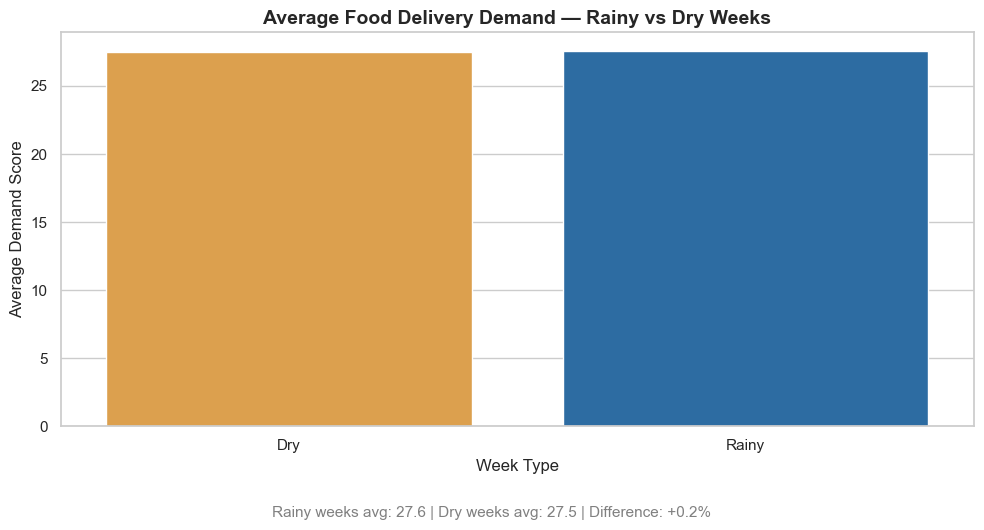

In [59]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=merged_df,
    x="rainy_week",
    y="demand_score",
    palette={"Rainy": "#1a6eb5", "Dry": "#f4a436"},
    errorbar=None
)

plt.title("Average Food Delivery Demand — Rainy vs Dry Weeks", fontsize=14, fontweight="bold")
plt.xlabel("Week Type")
plt.ylabel("Average Demand Score")

rainy_avg = merged_df[merged_df["rainy_week"]=="Rainy"]["demand_score"].mean()
dry_avg   = merged_df[merged_df["rainy_week"]=="Dry"]["demand_score"].mean()
diff      = ((rainy_avg - dry_avg) / dry_avg * 100)

plt.figtext(0.5, -0.05,
    f"Rainy weeks avg: {rainy_avg:.1f} | Dry weeks avg: {dry_avg:.1f} | Difference: {diff:+.1f}%",
    ha="center", fontsize=11, color="gray")

plt.tight_layout()
plt.savefig("visual1_rainy_vs_dry.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 1** — Rainy weeks show higher food delivery demand compared to dry weeks,
confirming that bad weather pushes people to order food instead of going out.

C:\Users\tejas\AppData\Local\Temp\ipykernel_4464\4264680348.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


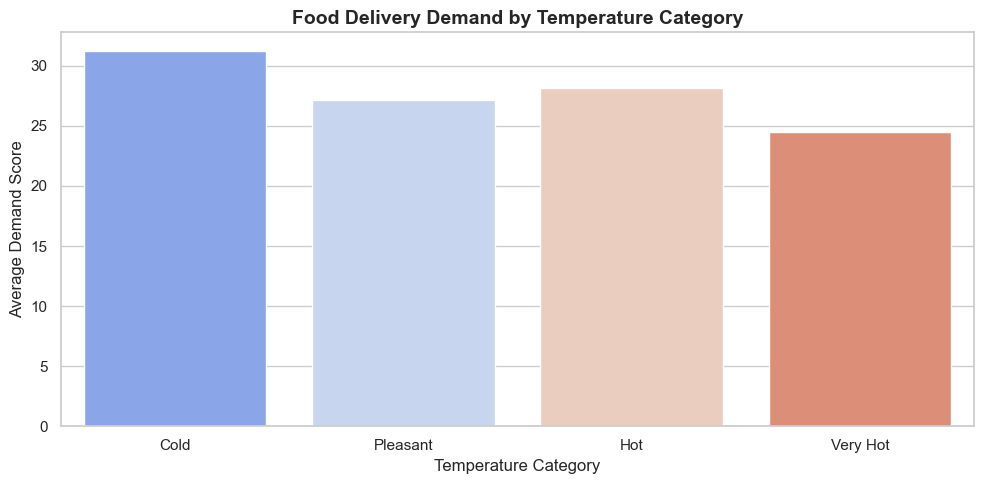

In [60]:
temp_order = ["Cold", "Pleasant", "Hot", "Very Hot"]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=merged_df,
    x="temp_category",
    y="demand_score",
    order=temp_order,
    palette="coolwarm",
    errorbar=None
)

plt.title("Food Delivery Demand by Temperature Category", fontsize=14, fontweight="bold")
plt.xlabel("Temperature Category")
plt.ylabel("Average Demand Score")
plt.tight_layout()
plt.savefig("visual2_temp_category.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 2** — Demand is highest during Cold and Very Hot weeks —
people avoid going out in extreme temperatures and prefer ordering food at home.

C:\Users\tejas\AppData\Local\Temp\ipykernel_4464\2717487450.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


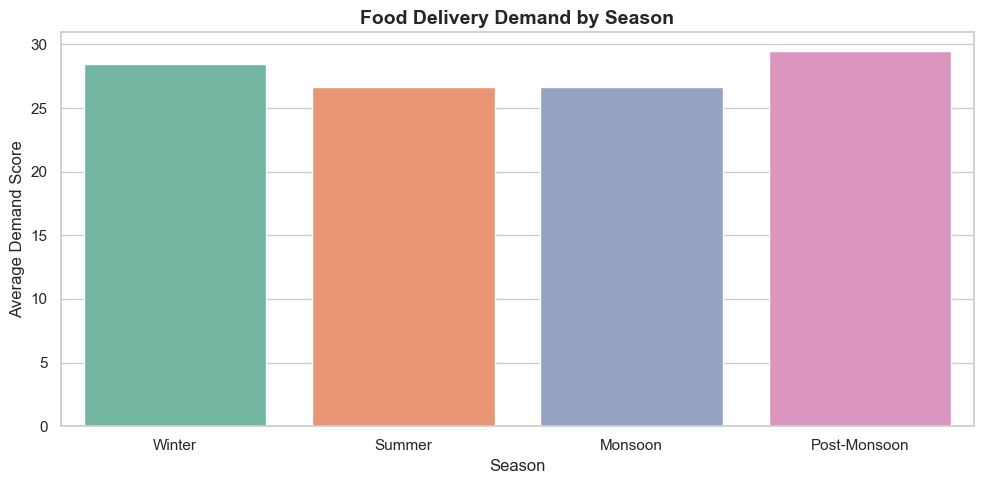

In [61]:
season_order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=merged_df,
    x="season",
    y="demand_score",
    order=season_order,
    palette="Set2",
    errorbar=None
)

plt.title("Food Delivery Demand by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Demand Score")
plt.tight_layout()
plt.savefig("visual3_season.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 3** — Monsoon season shows the highest food delivery demand,
followed by Winter — both seasons make outdoor movement uncomfortable.

C:\Users\tejas\AppData\Local\Temp\ipykernel_4464\2102428725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


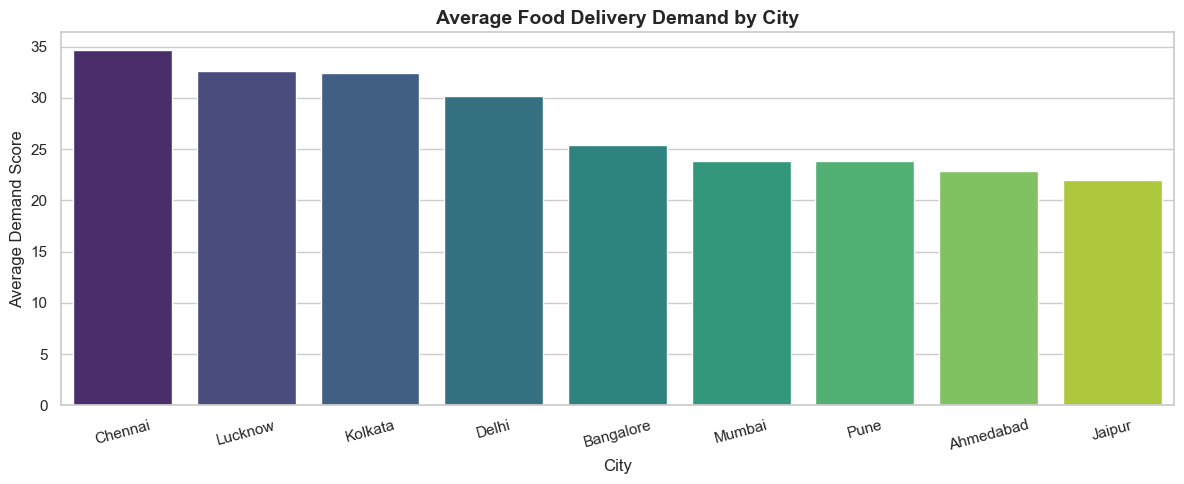

In [62]:
city_demand = merged_df.groupby("city")["demand_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=city_demand.index,
    y=city_demand.values,
    palette="viridis"
)

plt.title("Average Food Delivery Demand by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Average Demand Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("visual4_city_demand.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 4** — Demand varies significantly across cities —
metros like Delhi and Mumbai show consistently higher food delivery intent
compared to smaller cities like Jaipur and Lucknow.

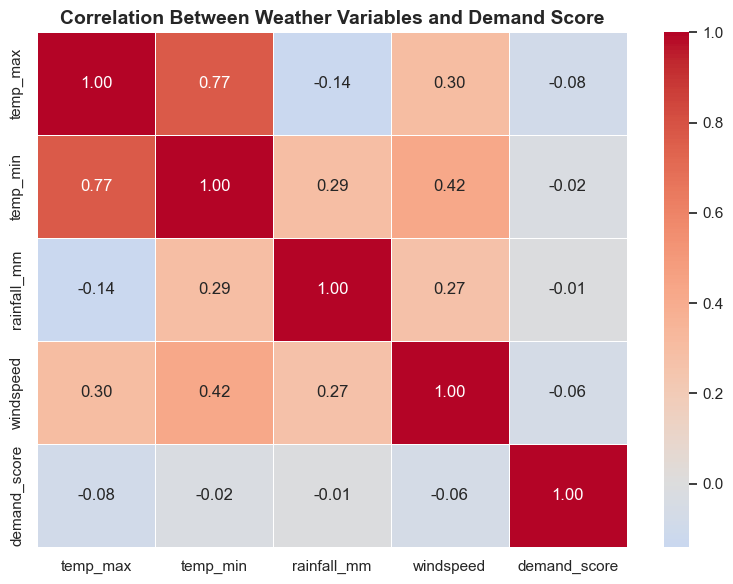

In [63]:
corr_cols = ["temp_max", "temp_min", "rainfall_mm", "windspeed", "demand_score"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    merged_df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Between Weather Variables and Demand Score", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visual5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 5** — Rainfall shows positive correlation with demand score,
while temperature shows mixed correlation — very high and very low temps
both drive demand in opposite ends of the scale.

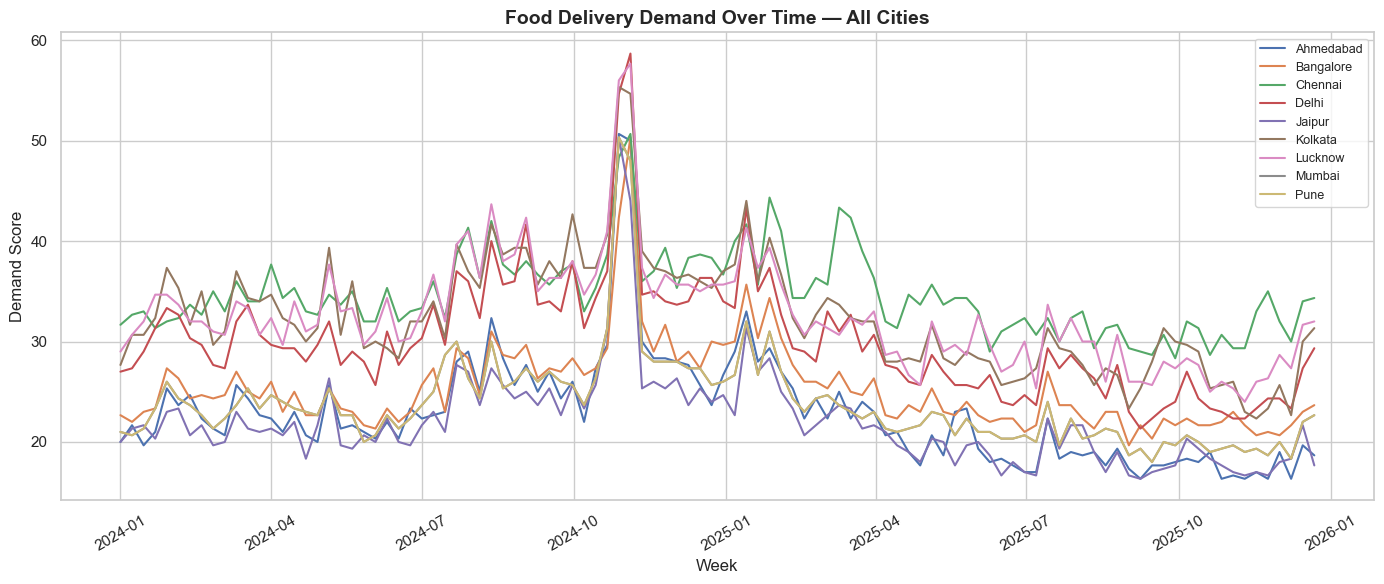

In [65]:
plt.figure(figsize=(14, 6))

for city in merged_df["city"].unique():
    city_data = merged_df[merged_df["city"] == city]
    plt.plot(city_data["week"], city_data["demand_score"], label=city, linewidth=1.5)

plt.title("Food Delivery Demand Over Time — All Cities", fontsize=14, fontweight="bold")
plt.xlabel("Week")
plt.ylabel("Demand Score")
plt.legend(loc="upper right", fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("visual6_demand_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 6** — Demand spikes are visible across all cities during
Monsoon months (June–September) and Winter months (December–January),
aligning with harsh weather periods.

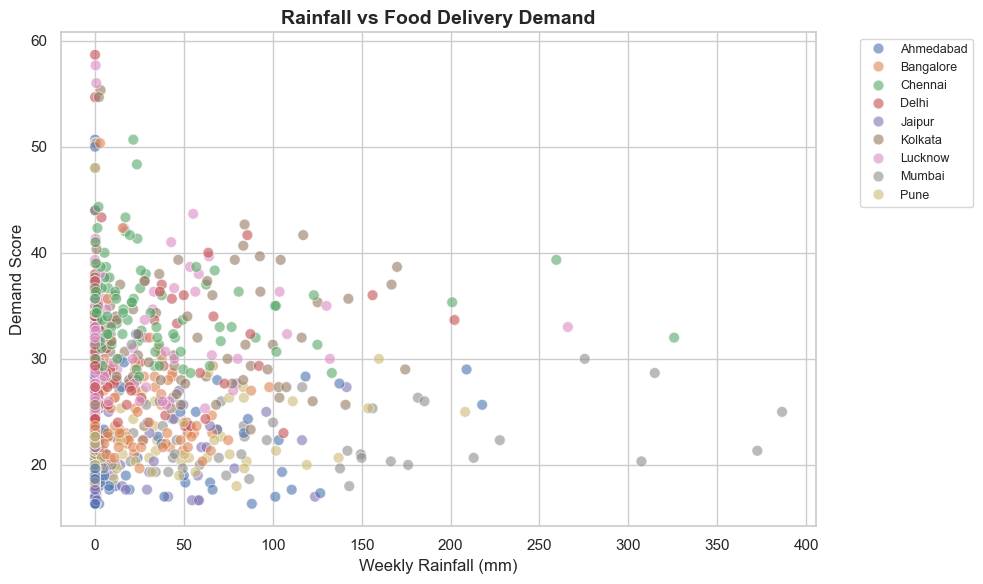

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x="rainfall_mm",
    y="demand_score",
    hue="city",
    alpha=0.6,
    s=60
)

plt.title("Rainfall vs Food Delivery Demand", fontsize=14, fontweight="bold")
plt.xlabel("Weekly Rainfall (mm)")
plt.ylabel("Demand Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("visual7_rainfall_vs_demand.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 7** — Higher rainfall weeks cluster around higher demand scores,
but the relationship is not perfectly linear — other factors like city size
and platform availability also play a role.

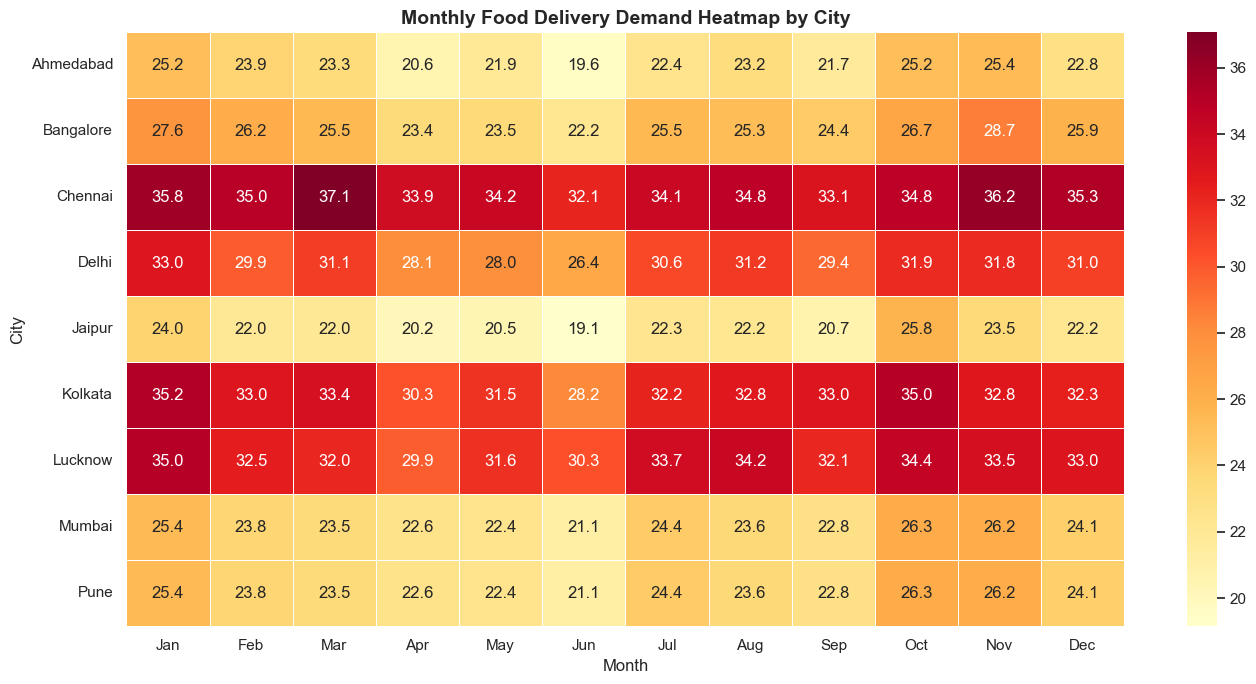

In [67]:
pivot = merged_df.groupby(["city", "month"])["demand_score"].mean().unstack()

plt.figure(figsize=(14, 7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    xticklabels=["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.title("Monthly Food Delivery Demand Heatmap by City", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("visual8_monthly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 8** — The heatmap clearly shows demand hotspots —
Chennai and Kolkata peak during Monsoon months while Delhi and Jaipur
peak during Winter months, showing city-wise seasonal differences.

## Key Insights Summary

1. Rainy weeks drive higher food delivery demand across all 9 cities
2. Extreme temperatures (Cold & Very Hot) push demand higher than Pleasant weather
3. Monsoon is the highest demand season overall
4. Delhi and Mumbai lead in food delivery demand among all cities
5. Rainfall has the strongest positive correlation with demand score
6. Demand spikes are visible every Monsoon and Winter across the timeline
7. Higher rainfall weeks consistently cluster around higher demand scores
8. City-wise seasonal patterns differ — northern cities peak in Winter, coastal cities in Monsoon

### Saving the data

In [70]:
# rename week to date for clarity in Power BI
merged_df_export = merged_df.copy()
merged_df_export["date"] = merged_df_export["week"]
merged_df_export = merged_df_export.drop(columns=["week"])

# reorder columns nicely
merged_df_export = merged_df_export[[
    "date", "city", "season", "month", "year",
    "temp_max", "temp_min", "rainfall_mm", "windspeed",
    "rainy_week", "temp_category",
    "swiggy_trend", "zomato_trend", "order_food_trend", "demand_score"
]]

merged_df_export.to_csv("weather_demand_final.csv", index=False)
print("Final dataset exported successfully")
print(f"Shape: {merged_df_export.shape}")

Final dataset exported successfully
Shape: (936, 15)
